# Végétation à Paris

<div class="alert alert-info" style="font-size:110%">
 <p>
 <h3>Activité</h3>
 </p>
 
 Localiser la couverture végétale à Paris, à partir d'image satellite Sentinel 2.
 
</div>

In [1]:
import rasterio as rio
from rasterio.plot import show, show_hist
from rasterio.mask import mask
from rasterio.features import shapes

import fiona
import pyproj

import numpy as np
import geopandas as gpd

import matplotlib
import matplotlib.pyplot as plt

## Découvrir la structure d'un fichier image

Une image est un ensemble de matrices auxquelles sont associées des métadonnées.

![image.png](img/image.png)

<div class="alert alert-info" style="font-size:110%">
 
 <ol>
    <li>Ouvrir l'image satellite de Paris (fichier : T31UDQ_20190705T105031_TCI_10m.tif), en couleurs naturelles, prise en juillet 2019.</li>
    <li>Afficher ses métadonnées :</li>
    <ul>
        <li>Le nom du fichier</li>
        <li>La projection</li>
        <li>La couverture spatiale</li>
        <li>Le nombre de bandes</li>
     </ul>
 </ol>
 
Les données sont disponibles dans le répertoire <b>data/images/</b>
</div>

In [2]:
with rio.open("../../data/PARIS/images/T31UDQ_20190705T105031_TCI_10m.tif") as ds:
    print(ds.meta)
    print(ds.files)
    print(ds.crs)
    print(ds.bounds)
    print(ds.count)

{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 1810, 'height': 978, 'count': 3, 'crs': CRS.from_epsg(32631), 'transform': Affine(10.0, 0.0, 443040.0,
       0.0, -10.0, 5416870.0)}
['../../data/PARIS/images/T31UDQ_20190705T105031_TCI_10m.tif']
EPSG:32631
BoundingBox(left=443040.0, bottom=5407090.0, right=461140.0, top=5416870.0)
3


<div class="alert alert-info" style="font-size:110%">

  <ul>
    <li>Lire et afficher les différentes bandes qui la composent</li>
    <li>Comparer le type de l'image et des bandes</li>
  </ul>

</div>

In [3]:
rgb_rast =  rio.open("../../data/PARIS/images/T31UDQ_20190705T105031_TCI_10m.tif")
rgb_bands = rgb_rast.read()

In [4]:
print(rgb_bands.dtype)
print(rgb_bands.shape)

uint8
(3, 978, 1810)


<div class="alert alert-info" style="font-size:110%">

  <ul>
    <li>Afficher l'image en couleurs naturelles</li>
  </ul>

</div>

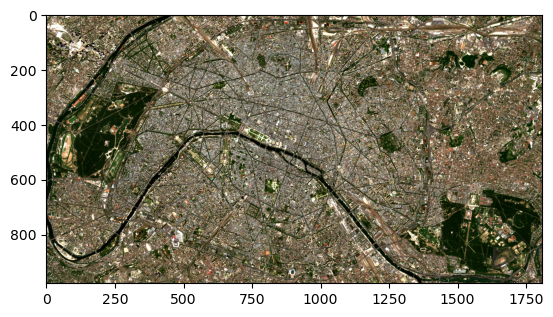

<Axes: >

In [5]:
show(rgb_bands)

### Faire une composition en fausses couleurs

Les composition en fausses couleurs infrarouge sont courantes pour faire ressortir visuellement des éléments  dans les infrarouges, notamment la végétation.

![Infrarouge.jpg](img/Infrarouge.jpg)  
*Image infrarouge, la végétation répond particulièrement bien au signal.*

<div class="alert alert-info" style="font-size:110%">

  <ul>
    <li>Lire la bande infrarouge prise au même moment (fichier : T31UDQ_20190705T105031_B08_10m.tif).</li>
    <li>Comparer les valeurs des pixels des bandes issus de l'image en couleurs naturelles et celles de la bande infrarouge.</li>
    <li>Afficher une composition en fausses couleurs, incluant la bande infrarouge.</li>
  </ul>

</div>

In [6]:
infr_rast = rio.open("../../data/PARIS/images/T31UDQ_20190705T105031_B08_10m.tif")
infr_band = infr_rast.read()

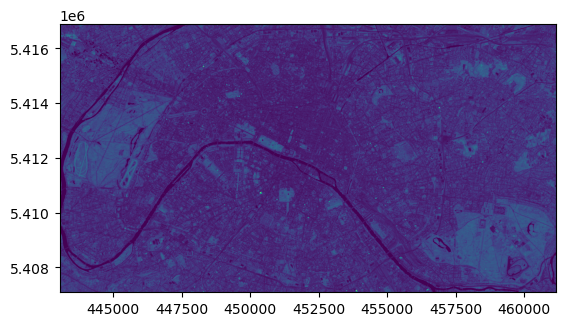

In [7]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
def add_cbar(ax, vmin, vmax, cmap="viridis", alpha=1):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
    cbar = matplotlib.colorbar.ColorbarBase(cax, cmap=cmap, norm=norm)
    cbar.solids.set_alpha(alpha)
    return cbar

vmin, vmax = np.min(infr_band), np.max(infr_band)
ax = show(infr_rast)
cb = add_cbar(ax, vmin, vmax)
cb.set_label("Infrared level")

### Calcul d'indice
Le calcul d'indice à partir de raster est une pratique courante pour faire ressortir certaines caractéristiques. Le plus connu de ces indices est le NDVI : *Normalized Difference Vegetation Index*, qui permet de mettre en évidence les zones de végétation.

Il se base sur les valeurs des pixels dans les bandes R et PIR :

$NDVI = \frac{PIR-R}{PIR+R}$

Cet indice est compris entre -1 et 1. Ses valeurs sont généralement interprétées selon l'échelle suivante :
* Les valeurs négatives correspondent à des surfaces composées essentiellement d'eau (neige, cours d'eau, etc.)
* Les pixels avec des valeurs autour de zéro décrivent des sols nus ou artificialisés
* Entre 0.2 et 0.3 (*approximativement*), les pixels représentent des zones de basse végétation (arbustes, prairies, etc.)
* Les valeurs les plus élevées ((*approximativement*) 0.6-0.8) indiquent des surfaces à haute végétation (forêts)

<div class="alert alert-info" style="font-size:110%">

  <ul>
    <li>Calculer le NDVI au 5 juillet 2019.</li>
    <li>Sauver le résultat dans un fichier image.</li>
    <li>Afficher le NDVI, avec la palette de couleur "RdYlGn"</li>
  </ul>

Bien se souvenir qu'une image est un ensemble de matrice(s) et de métadonnées. Une/des matrice(s) ne pourront s'enregistrer seule(s) sans métadonnée.

</div>

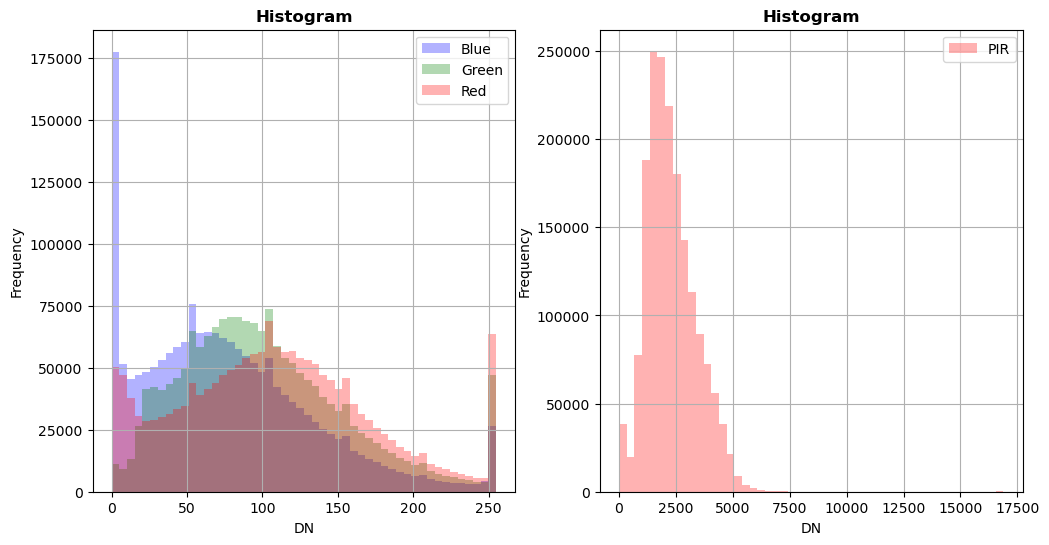

In [8]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 6))
show_hist(rgb_rast, bins=50, ax=axes[0], label=["Red", "Green", "Blue"], alpha=0.3, histtype="stepfilled")
show_hist(infr_rast, bins=50, ax=axes[1], label="PIR", alpha=0.3, histtype="stepfilled")


In [9]:
def normalize(band):
    band_min, band_max = band.min(), band.max()
    normalized = ((band - band_min)/(band_max - band_min)) * 255
    return normalized.astype(int)

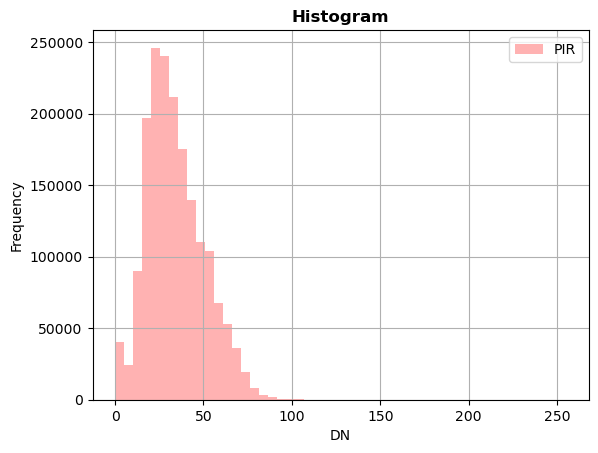

In [10]:
pirn = normalize(infr_band)
show_hist(pirn, bins=50, label="PIR", alpha=0.3, histtype="stepfilled")

### Create false color composite

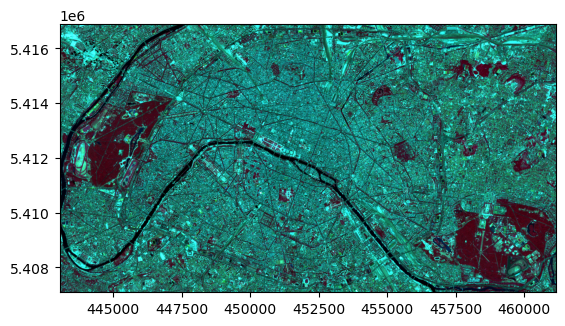

<Axes: >

In [11]:
pirn_rv = np.stack((pirn[0], rgb_bands[0], rgb_bands[1]))
show(pirn_rv, transform=rgb_rast.transform)

### Calculate NDVI

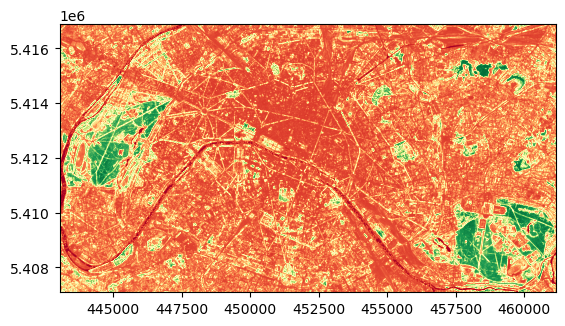

<Axes: >

In [12]:
red, green, blue = rgb_bands
ndvi = np.divide(pirn - red, pirn + red, out = np.zeros(pirn.shape, dtype="float64"), where=(pirn + red)!=0)
show(ndvi, cmap="RdYlGn", transform=rgb_rast.transform)

### Découpe de l'image

<div class="alert alert-info" style="font-size:110%">

  <ul>
    <li>Découper le NDVI selon les limites de Paris.</li>
    <li>Afficher le résultat avec la même palette de couleurs que ci-dessus.</li>
  </ul>

Un fichier vectoriel avec les limites de Paris se trouve dans **data/PARIS/limites_paris.geojson**

</div>

<Axes: >

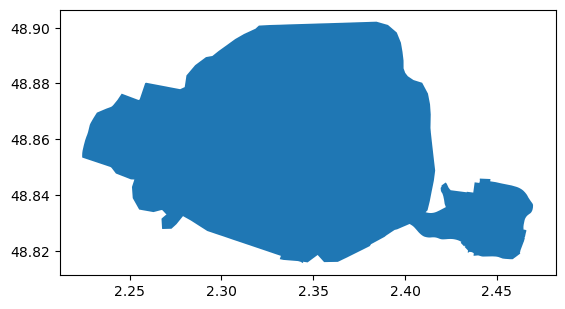

In [13]:
paris_shape = gpd.read_file("../../data/PARIS/limites_paris.geojson")
paris_shape.plot()

In [14]:
meta = infr_rast.meta
print(meta)
new_meta = meta.copy()
new_meta.update({"dtype":"float64"})
print(new_meta)
with rio.open('../../data/PARIS/images/ndvi.tif', "w", **new_meta) as dest:
 dest.write(ndvi)

{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': None, 'width': 1810, 'height': 978, 'count': 1, 'crs': CRS.from_epsg(32631), 'transform': Affine(10.0, 0.0, 443040.0,
       0.0, -10.0, 5416870.0)}
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 1810, 'height': 978, 'count': 1, 'crs': CRS.from_epsg(32631), 'transform': Affine(10.0, 0.0, 443040.0,
       0.0, -10.0, 5416870.0)}


In [15]:
ndvi_rst = rio.open("../../data/PARIS/images/ndvi.tif")

### Extraire les zones de végétation

<div class="alert alert-info" style="font-size:110%">

  <ul>
    <li>Appliquer un seuil sur le NDVI pour extraire les zone végétalisées.</li>
    <li>Sauver les zones extraites dans un fichier vectoriel.</li>
  </ul>

</div>

In [16]:
seuil_veg = 0.2
seuil_eau = -0.9

In [17]:
paris_classif = np.ones(ndvi.shape)
paris_classif[np.isnan(ndvi)] = 10
paris_classif[(ndvi > seuil_veg) & (paris_classif < 10)] = 2
paris_classif[(ndvi <= seuil_eau) & (paris_classif < 10)] = 0

In [18]:
np.unique(paris_classif)
#plt.imshow(ndvi.squeeze())
#plt.figure()
#plt.imshow(paris_classif.squeeze())

array([0., 1., 2.])

In [19]:
# out_image, out_transform = rio.mask.mask(src, shapes, crop=True)

# mon_raster_clip, mon_raster_clip_transform = mask(dataset=ndvi,
#  shapes=masque_geom,
#  crop=True,
#  nodata=-9999)